#### 1. Load and explore the dataset

In [23]:
import numpy as np
import pandas as pd

# Load the three CSV files
orders_df = pd.read_csv('Orders.csv', encoding='latin1')
returns_df = pd.read_csv('returns.csv', encoding='latin1')
people_df = pd.read_csv('people.csv', encoding='latin1')

# 1. Inspect shapes
print(f'Orders shape: {orders_df.shape}')
print(f'Returns shape: {returns_df.shape}')
print(f'People shape: {people_df.shape}')

# 2. Convert Date columns to datetime format
orders_df['Order Date'] = pd.to_datetime(orders_df['Order Date'])
orders_df['Ship Date'] = pd.to_datetime(orders_df['Ship Date'])

# 3. Check for missing values and duplicates in Orders
print('\n--- Missing Values in Orders ---')
missing = orders_df.isnull().sum()
print(missing[missing > 0])

print(f'\nDuplicate rows in Orders: {orders_df.duplicated().sum()}')

Orders shape: (51290, 24)
Returns shape: (2033, 3)
People shape: (24, 2)

--- Missing Values in Orders ---
Postal Code    41296
dtype: int64

Duplicate rows in Orders: 0


In [39]:
orders_df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping Duration,Order_Year,Order_Month_Year
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Furniture,731.82,2,0.0,102.42,39.66,Medium,7,2017,2017-03
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Office Supplies,243.54,9,0.0,104.49,18.72,Medium,3,2015,2015-09
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Technology,346.32,3,0.0,13.77,14.10,Medium,7,2017,2017-03
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,Furniture,169.68,4,0.0,79.68,11.01,Medium,7,2017,2017-03
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,Office Supplies,203.88,4,0.0,24.36,5.72,Medium,3,2015,2015-09


In [37]:
returns_df

,Returned,Order ID,Region
0,Yes,IN-2017-CA120551-42816,Southern Asia
1,Yes,IN-2017-AA103751-42926,Southern Asia
2,Yes,IN-2017-TS212051-42904,Southern Asia
3,Yes,AG-2014-RO97803-41695,North Africa
4,Yes,AG-2015-LC70503-42265,North Africa
...,...,...,...
2028,Yes,ZA-2017-BT1395147-43067,Eastern Africa
2029,Yes,ZA-2016-TH11235147-42444,Eastern Africa
2030,Yes,ZA-2015-DN3690147-42159,Eastern Africa
2031,Yes,ZA-2016-TH11235147-42444,Eastern Africa


In [41]:
people_df.head(5)

,Person,Region
0,MarilÃ¨ne Rousseau,\tCaribbean
1,AndileÂ Ihejirika,\tCentral Africa
2,Nicodemo Bautista,\tCentral America
3,Cansu Peynirci,\tCentral Asia
4,Lon Bonher,\tCentral US


**Exploring Series vs. DataFrames**
- In Pandas, a DataFrame is a 2D table (rows and columns), while a Series is a single column (1D array).

In [24]:
# A DataFrame has multiple columns (e.g., shape is 51290 rows, 24 columns)
print('Type of orders_df:', type(orders_df))

# Selecting a single column returns a Pandas Series
customer_series = orders_df['Customer Name']
print('Type of customer_series:', type(customer_series))
print('\nFirst 5 items of the Series:\n', customer_series.head())

Type of orders_df: <class 'pandas.DataFrame'>
Type of customer_series: <class 'pandas.Series'>

First 5 items of the Series:
 0    Cathy Armstrong
1       Brian Dahlen
2    Cathy Armstrong
3    Cathy Armstrong
4       Brian Dahlen
Name: Customer Name, dtype: str


**Selecting Specific Rows and Columns**

In [25]:
# Selecting specific columns (returns a DataFrame)
subset_df = orders_df[['Customer Name', 'Category', 'Sales']]
display(subset_df.head(3))

# Using .loc[] to select specific rows (e.g., rows 0 to 4) and specific columns
some_rows_cols = orders_df.loc[0:4, ['Order ID', 'Order Date', 'Sales']]
display(some_rows_cols)

# Using .iloc[] to select rows 0 through 4 and columns 0 through 3 (using integer positions)
integer_selection = orders_df.iloc[0:5, 0:4]
display(integer_selection)

,Customer Name,Category,Sales
0,Cathy Armstrong,Furniture,731.82
1,Brian Dahlen,Office Supplies,243.54
2,Cathy Armstrong,Technology,346.32


,Order ID,Order Date,Sales
0,IN-2017-CA120551-42816,2017-03-22,731.82
1,ID-2015-BD116051-42248,2015-09-01,243.54
2,IN-2017-CA120551-42816,2017-03-22,346.32
3,IN-2017-CA120551-42816,2017-03-22,169.68
4,ID-2015-BD116051-42248,2015-09-01,203.88


,Row ID,Order ID,Order Date,Ship Date
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04


**Filtering Data Using Relevant Conditions**


In [26]:
# Condition 1: Orders in the 'Technology' category
tech_orders = orders_df[orders_df['Category'] == 'Technology']
print(f'Total Technology orders: {tech_orders.shape[0]}')

# Condition 2: Multiple conditions (Technology category AND Sales greater than 1000)
high_value_tech = orders_df[
    (orders_df['Category'] == 'Technology') & (orders_df['Sales'] > 1000)
]
print(f'High-value Technology orders (Sales > 1000): {high_value_tech.shape[0]}')

# Condition 3: Using .isin() to filter for multiple regions (e.g., 'Central' or 'South')
regional_orders = orders_df[orders_df['Region'].isin(['Central', 'South'])]
print(f'Orders in Central or South regions: {regional_orders.shape[0]}')

Total Technology orders: 10141
High-value Technology orders (Sales > 1000): 1119
Orders in Central or South regions: 0


#### 2. Clean and prepare the data

In [42]:

# Load the datasets CSV files
orders_df = pd.read_csv('Orders.csv', encoding='latin1')
returns_df = pd.read_csv('returns.csv', encoding='latin1')
people_df = pd.read_csv('people.csv', encoding='latin1')

# --- 1. Identify Missing Values ---
print('--- Missing Values in Orders ---')
missing_counts = orders_df.isnull().sum()
print(missing_counts[missing_counts > 0])

# Fill missing Postal Codes with a placeholder if needed
if 'Postal Code' in orders_df.columns:
  orders_df['Postal Code'] = orders_df['Postal Code'].fillna('Unknown')

# --- 2. Check for Duplicate Records ---
duplicates = orders_df.duplicated().sum()
print(f'\nNumber of duplicate rows in Orders: {duplicates}')

# --- 3. Check and Correct Data Types ---
print('\n--- Data Types Before Conversion ---')
print(orders_df[['Order Date', 'Ship Date']].dtypes)

# Convert Order Date and Ship Date to datetime format
orders_df['Order Date'] = pd.to_datetime(orders_df['Order Date'])
orders_df['Ship Date'] = pd.to_datetime(orders_df['Ship Date'])

print('\n--- Data Types After Conversion ---')
print(orders_df[['Order Date', 'Ship Date']].dtypes)

# --- 4. Create Useful Calculated Columns ---
# Shipping Duration: Number of days between Order Date and Ship Date
orders_df['Shipping Duration'] = (
    orders_df['Ship Date'] - orders_df['Order Date']
).dt.days

# Profit Margin: Profit as a percentage of Sales
orders_df['Profit Margin'] = (orders_df['Profit'] / orders_df['Sales']) * 100

# Preview the newly created columns
print('\n--- Preview of Prepared Data & New Columns ---')
display(
    orders_df[
        [
            'Order ID',
            'Order Date',
            'Ship Date',
            'Shipping Duration',
            'Sales',
            'Profit',
            'Profit Margin',
        ]
    ].head(5)
)

--- Missing Values in Orders ---
Postal Code    41296
dtype: int64

Number of duplicate rows in Orders: 0

--- Data Types Before Conversion ---
Order Date    str
Ship Date     str
dtype: object

--- Data Types After Conversion ---
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

--- Preview of Prepared Data & New Columns ---


,Order ID,Order Date,Ship Date,Shipping Duration,Sales,Profit,Profit Margin
0,IN-2017-CA120551-42816,2017-03-22,2017-03-29,7,731.82,102.42,13.995245
1,ID-2015-BD116051-42248,2015-09-01,2015-09-04,3,243.54,104.49,42.904656
2,IN-2017-CA120551-42816,2017-03-22,2017-03-29,7,346.32,13.77,3.976091
3,IN-2017-CA120551-42816,2017-03-22,2017-03-29,7,169.68,79.68,46.958982
4,ID-2015-BD116051-42248,2015-09-01,2015-09-04,3,203.88,24.36,11.948205


#### 3. Perfom Operations on the Data

In [28]:

orders_df = pd.read_csv('Orders.csv', encoding='latin1')

# Ensure date columns are in datetime format
orders_df['Order Date'] = pd.to_datetime(orders_df['Order Date'])
orders_df['Ship Date'] = pd.to_datetime(orders_df['Ship Date'])

# --- 1. Calculations ---
total_sales = orders_df['Sales'].sum()
total_profit = orders_df['Profit'].sum()
total_quantity = orders_df['Quantity'].sum()
avg_discount = orders_df['Discount'].mean()
total_shipping_cost = orders_df['Shipping Cost'].sum()

print(f'Total Sales: {total_sales:,.2f}')
print(f'Total Profit: {total_profit:,.2f}')
print(f'Total Quantity Sold: {total_quantity:,}')
print(f'Average Discount: {avg_discount:.2%}')
print(f'Total Shipping Cost: {total_shipping_cost:,.2f}')

# --- 2. Calculated Columns ---
# Shipping Duration: Number of days between Order Date and Ship Date
orders_df['Shipping Duration'] = (
    orders_df['Ship Date'] - orders_df['Order Date']
).dt.days

# Profit Margin: Profit as a percentage of sales
orders_df['Profit Margin'] = (orders_df['Profit'] / orders_df['Sales']) * 100

print(
    f'Average Shipping Duration: {orders_df["Shipping Duration"].mean():.2f} days'
)

# --- 3. Products/Orders with Highest and Lowest Profit Margins ---
print('\n--- Top 5 Highest Profit Margins ---')
highest_margins = orders_df.nlargest(5, 'Profit Margin')[
    ['Product Name', 'Sales', 'Profit', 'Profit Margin']
]
display(highest_margins)

print('\n--- Top 5 Lowest (or Most Negative) Profit Margins ---')
lowest_margins = orders_df.nsmallest(5, 'Profit Margin')[
    ['Product Name', 'Sales', 'Profit', 'Profit Margin']
]
display(lowest_margins)

Total Sales: 12,642,501.91
Total Profit: 1,467,457.29
Total Quantity Sold: 178,312
Average Discount: 14.29%
Total Shipping Cost: 1,358,085.70
Average Shipping Duration: 3.97 days

--- Top 5 Highest Profit Margins ---


,Product Name,Sales,Profit,Profit Margin
241,"KitchenAid Refrigerator, White",1052.16,526.08,50.0
780,"Advantus Door Stop, Durable",42.06,21.03,50.0
1115,"Fellowes File Cart, Single Width",274.68,137.34,50.0
1721,"Novimex Legal Exhibit Labels, 5000 Label Set",21.72,10.86,50.0
1755,"Fellowes File Cart, Single Width",274.68,137.34,50.0



--- Top 5 Lowest (or Most Negative) Profit Margins ---


,Product Name,Sales,Profit,Profit Margin
16441,"Chromcraft Coffee Table, Fully Assembled",241.704,-1144.116,-473.354185
39004,"Deflect-O Clock, Black",70.434,-271.236,-385.092427
31529,"Hon Coffee Table, Fully Assembled",63.474,-244.386,-385.017487
31692,"Hon Coffee Table, Fully Assembled",126.948,-488.772,-385.017487
31728,"Lesro Training Table, Adjustable Height",108.396,-390.264,-360.035426


#### 4. Combine the Datasets

In [29]:


# Clean column names to remove any accidental trailing spaces
orders_df.columns = orders_df.columns.str.strip()
people_df.columns = people_df.columns.str.strip()
returns_df.columns = returns_df.columns.str.strip()

# --- 1. Merge Orders with People ---
# We use a left join on 'Region' so every order keeps its row, paired with its assigned sales person.
orders_merged = pd.merge(orders_df, people_df, on='Region', how='left')

# --- 2. Merge Orders with Returns ---
# We use a left join on 'Order ID' to identify returned orders.
orders_merged = pd.merge(
    orders_merged, returns_df[['Order ID', 'Returned']], on='Order ID', how='left'
)

# Fill missing return values with 'No'
orders_merged['Returned'] = orders_merged['Returned'].fillna('No')

# --- 3. Verify the Merged DataFrame ---
print(f'Original Orders rows: {orders_df.shape[0]}')
print(f'Merged Orders rows: {orders_merged.shape[0]}')
print('\nSample of merged columns (including Person and Returned):')
display(
    orders_merged[
        ['Order ID', 'Region', 'Person', 'Sales', 'Profit', 'Returned']
    ].head(5)
)

Original Orders rows: 51290
Merged Orders rows: 51593

Sample of merged columns (including Person and Returned):


,Order ID,Region,Person,Sales,Profit,Returned
0,IN-2017-CA120551-42816,Southern Asia,NaN,731.82,102.42,Yes
1,ID-2015-BD116051-42248,Southern Asia,NaN,243.54,104.49,No
2,IN-2017-CA120551-42816,Southern Asia,NaN,346.32,13.77,Yes
3,IN-2017-CA120551-42816,Southern Asia,NaN,169.68,79.68,Yes
4,ID-2015-BD116051-42248,Southern Asia,NaN,203.88,24.36,No


**Why I used merge() instead of concat()**
- merge() is used for relational joining (like SQL joins). It combines datasets horizontally based on common columns or keys (e.g., matching Region or Order ID), which is precisely what we need when connecting separate lookup tables like People and Returns to our main Orders table.
- concat() is used for stacking datasets vertically (appending rows) or horizontally when they share the exact same structure or index (e.g., combining 2014 orders and 2015 orders stored in separate files).

#### 5. Group and Aggregate the Data

In [30]:


orders_df.columns = orders_df.columns.str.strip()
people_df.columns = people_df.columns.str.strip()
returns_df.columns = returns_df.columns.str.strip()

orders_merged = pd.merge(orders_df, people_df, on='Region', how='left')

# --- 1. Aggregate Performance by Market ---
print('--- Performance by Market ---')
market_perf = (
    orders_merged.groupby('Market')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Sales=('Sales', 'mean'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Orders=('Order ID', 'nunique'),
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)
display(market_perf)

# --- 2. Aggregate Performance by Category ---
print('\n--- Performance by Category ---')
category_perf = (
    orders_merged.groupby('Category')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Sales=('Sales', 'mean'),
        Total_Quantity=('Quantity', 'sum'),
    )
    .reset_index()
    .sort_values(by='Total_Profit', ascending=False)
)
display(category_perf)

# --- 3. Aggregate Performance by Customer Segment ---
print('\n--- Performance by Customer Segment ---')
segment_perf = (
    orders_merged.groupby('Segment')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Order_Count=('Order ID', 'nunique'),
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)
display(segment_perf)

# --- 4. Aggregate Performance by Region ---
region_perf = (
    orders_merged.groupby('Region')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Sales=('Sales', 'mean'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Orders=('Order ID', 'nunique'),
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)

print('--- Performance by Region (Top 5) ---')
display(region_perf.head(5))

--- Performance by Market ---


,Market,Total_Sales,Total_Profit,Avg_Sales,Total_Quantity,Total_Orders
1,Asia Pacific,4.042658e+06,403176.03800,282.663842,48597,7080
2,Europe,3.287336e+06,449551.72350,280.274212,41919,6013
4,USCA,2.364129e+06,304214.41170,227.801988,38706,5203
3,LATAM,2.164605e+06,221643.48708,210.278334,38526,5144
0,Africa,7.837732e+05,88871.63100,170.868370,10564,2288



--- Performance by Category ---


,Category,Total_Sales,Total_Profit,Avg_Sales,Total_Quantity
2,Technology,4.744557e+06,663778.73318,467.858939,35176
1,Office Supplies,3.787493e+06,518595.82790,121.048692,108244
0,Furniture,4.110452e+06,285082.73020,416.881531,34892



--- Performance by Customer Segment ---


,Segment,Total_Sales,Total_Profit,Order_Count
0,Consumer,6.507949e+06,749239.78206,13291
1,Corporate,3.824698e+06,441208.32866,7724
2,Home Office,2.309855e+06,277009.18056,4713


--- Performance by Region (Top 5) ---


,Region,Total_Sales,Total_Profit,Avg_Sales,Total_Quantity,Total_Orders
21,Western Europe,1.731930e+06,218433.50850,294.395660,22262,2993
3,Central America,1.223101e+06,158981.64816,217.788573,20882,2831
12,Oceania,1.100185e+06,120089.11200,315.510356,12838,1743
14,Southeastern Asia,8.844232e+05,17852.32900,282.653617,11822,1517
16,Southern Asia,8.665727e+05,159336.42700,326.392722,9109,1346


**Calculate appropriate statistics such as total sales, total profit, average sales, quantity sold, or number of orders.**


In [31]:

# Calculate core metrics
total_sales = orders_df['Sales'].sum()
total_profit = orders_df['Profit'].sum()
avg_sales = orders_df['Sales'].mean()
total_quantity = orders_df['Quantity'].sum()
total_orders = orders_df['Order ID'].nunique()

print(f'Overall Total Sales: ${total_sales:,.2f}')
print(f'Overall Total Profit: ${total_profit:,.2f}')
print(f'Average Sales per Order: ${avg_sales:,.2f}')
print(f'Total Quantity Sold: {total_quantity:,}')
print(f'Total Number of Unique Orders: {total_orders:,}')

Overall Total Sales: $12,642,501.91
Overall Total Profit: $1,467,457.29
Average Sales per Order: $246.49
Total Quantity Sold: 178,312
Total Number of Unique Orders: 25,728


### 6. Create a Pivot Table

-  In Pandas, pivot tables are created using the .pivot_table() method.
-  They allow you to aggregate data across two or more dimensions (using index and columns) while applying aggregation functions (aggfunc) like sum, mean, or count to specific metric columns (values).

In [32]:

# --- 1. Pivot Table: Total Sales by Market (Rows) and Category (Columns) ---
market_category_pivot = orders_df.pivot_table(
    values='Sales',
    index='Market',
    columns='Category',
    aggfunc='sum',
    fill_value=0,
)

print('--- Pivot Table: Total Sales by Market and Category ---')
display(market_category_pivot)

# --- 2. Pivot Table: Total Profit by Segment (Rows) and Region (Columns) ---
# (Using a subset of top regions or all regions depending on preference)
segment_region_pivot = orders_df.pivot_table(
    values='Profit', index='Segment', columns='Region', aggfunc='sum', fill_value=0
)

print('\n--- Pivot Table: Total Profit by Segment and Region ---')

--- Pivot Table: Total Sales by Market and Category ---


Category,Furniture,Office Supplies,Technology
Market,,,
Africa,1.946506e+05,2.667555e+05,3.223670e+05
Asia Pacific,1.461551e+06,1.043652e+06,1.537455e+06
Europe,8.901066e+05,1.163661e+06,1.233569e+06
LATAM,8.119706e+05,5.639207e+05,7.887138e+05
USCA,7.521728e+05,7.495034e+05,8.624528e+05



--- Pivot Table: Total Profit by Segment and Region ---


#### 7. Working with strings

In [33]:

# --- 1. How many products contain the word "Chair"? ---
# Using case=False to catch both "chair" and "Chair"
chair_mask = orders_df['Product Name'].str.contains('Chair', case=False, na=False)
total_chair_rows = chair_mask.sum()
unique_chair_products = orders_df[chair_mask]['Product Name'].nunique()

print(f'Total order rows containing "Chair": {total_chair_rows:,}')
print(f'Unique products containing "Chair": {unique_chair_products:,}')

# --- 2. How many customers have the word "Smith" in their name? ---
smith_mask = orders_df['Customer Name'].str.contains('Smith', case=False, na=False)
unique_smith_customers = orders_df[smith_mask]['Customer Name'].nunique()

print(f'Unique customers with "Smith" in their name: {unique_smith_customers}')

# --- 3. Create a new column containing the first word of each Product Name ---
# .str.split() splits by whitespace by default, and .str[0] extracts the first element
orders_df['Product_First_Word'] = orders_df['Product Name'].str.split().str[0]

print('\n--- Preview of Product First Word Column ---')
display(orders_df[['Product Name', 'Product_First_Word']].head(5))

# --- 4. Which five first words appear most frequently in Product Names? ---
top_first_words = orders_df['Product_First_Word'].value_counts().head(5)

print('\n--- Top 5 Most Frequent First Words in Product Names ---')
print(top_first_words)

Total order rows containing "Chair": 3,022
Unique products containing "Chair": 206
Unique customers with "Smith" in their name: 5

--- Preview of Product First Word Column ---


,Product Name,Product_First_Word
0,"Ikea Library with Doors, Mobile",Ikea
1,"Acme Scissors, Easy Grip",Acme
2,"Epson Receipt Printer, White",Epson
3,"Rubbermaid Door Stop, Erganomic",Rubbermaid
4,"Cameo Interoffice Envelope, with clear poly wi...",Cameo



--- Top 5 Most Frequent First Words in Product Names ---
Product_First_Word
Avery    1916
Eldon    1471
Hon      1330
Tenex    1323
Smead    1303
Name: count, dtype: int64


### 8. Analyze sales over time

Average Shipping Duration: 3.97 days

--- Yearly Performance Trends ---


,Order_Year,Total_Sales,Total_Profit,Total_Orders
0,2014,2.259451e+06,248940.81154,4515
1,2015,2.677439e+06,307415.27910,5473
2,2016,3.405746e+06,406935.23018,6883
3,2017,4.299866e+06,504165.97046,8857


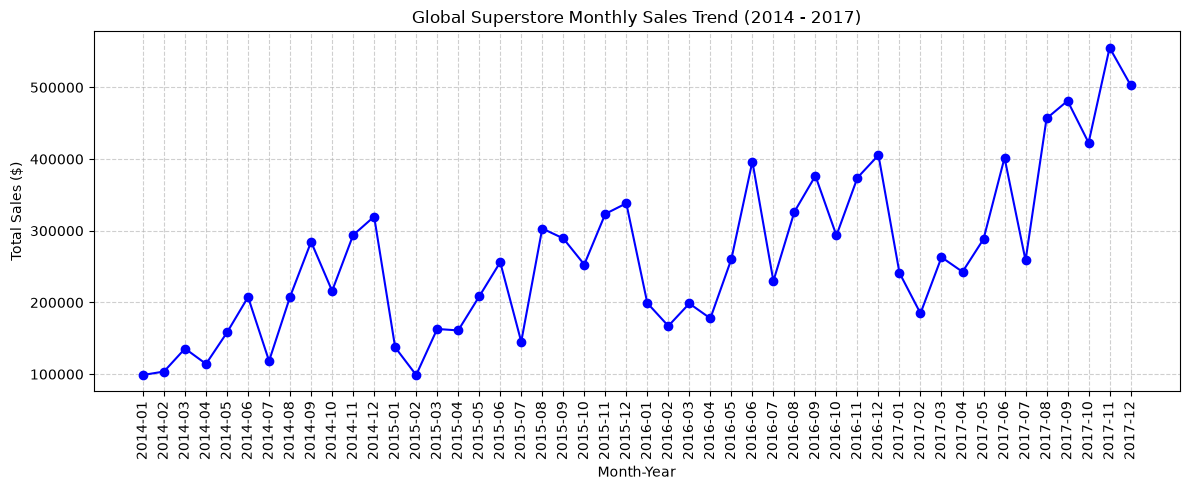

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset and clean column names
orders_df = pd.read_csv('Orders.csv', encoding='latin1')
orders_df.columns = orders_df.columns.str.strip()

# --- 1. Convert Order Date and Ship Date to datetime format ---
orders_df['Order Date'] = pd.to_datetime(orders_df['Order Date'])
orders_df['Ship Date'] = pd.to_datetime(orders_df['Ship Date'])

# --- 2. Calculate Shipping Duration ---
orders_df['Shipping Duration'] = (
    orders_df['Ship Date'] - orders_df['Order Date']
).dt.days
print(
    f'Average Shipping Duration: {orders_df["Shipping Duration"].mean():.2f} days'
)

# --- 3. Analyze Sales and Profit Over Time (Yearly & Monthly) ---
orders_df['Order_Year'] = orders_df['Order Date'].dt.year
orders_df['Order_Month_Year'] = orders_df['Order Date'].dt.to_period('M')

yearly_perf = (
    orders_df.groupby('Order_Year')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Total_Orders=('Order ID', 'nunique'),
    )
    .reset_index()
)

print('\n--- Yearly Performance Trends ---')
display(yearly_perf)

# --- 4. Visualize Monthly Sales Trend ---
monthly_perf = (
    orders_df.groupby('Order_Month_Year')
    .agg(Total_Sales=('Sales', 'sum'))
    .reset_index()
)
monthly_perf['Order_Month_Year'] = monthly_perf['Order_Month_Year'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_perf['Order_Month_Year'],
    monthly_perf['Total_Sales'],
    marker='o',
    color='b',
    linestyle='-',
)
plt.xticks(rotation=90)
plt.title('Global Superstore Monthly Sales Trend (2014 - 2017)')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### 9. Use heirachical index
- In Pandas, Hierarchical Indexing (MultiIndex) allows you to set multiple index levels on a DataFrame or Series. This is extremely powerful for grouping data across two or more dimensions

In [35]:

# --- 1. Create a MultiIndex Grouped by Market and Category ---
multi_agg = orders_df.groupby(['Market', 'Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
)

print('--- MultiIndex DataFrame Sample ---')
display(multi_agg.head(6))

# --- 2. Select and Analyze Specific Groups Using .loc ---
# Select all categories for a specific market (e.g., 'Europe')
print('\n--- Performance for Europe (All Categories) ---')
display(multi_agg.loc['Europe'])

# Select a precise multi-index tuple combination (e.g., 'Asia Pacific' and 'Technology')
print('\n--- Specific Group: Asia Pacific & Technology ---')
asia_tech = multi_agg.loc[('Asia Pacific', 'Technology')]
print(f'Total Sales: ${asia_tech["Total_Sales"]:,.2f}')
print(f'Total Profit: ${asia_tech["Total_Profit"]:,.2f}')

# --- 3. Optional: Unstacking the MultiIndex into a Wide Table ---
# .unstack() transforms the inner index level into columns for side-by-side comparison
wide_table = multi_agg['Total_Sales'].unstack(level='Category')
print('\n--- Unstacked View (Sales by Market and Category) ---')
display(wide_table)

--- MultiIndex DataFrame Sample ---


Total_Sales  Total_Profit  Total_Quantity
Market       Category                                                   
Africa       Furniture        1.946506e+05    16262.0850            1431
             Office Supplies  2.667555e+05    28480.0530            7102
             Technology       3.223670e+05    44129.4930            2031
Asia Pacific Furniture        1.461551e+06   113375.2395           10169
             Office Supplies  1.043652e+06    92730.7355           27948
             Technology       1.537455e+06   197070.0630           10480


--- Performance for Europe (All Categories) ---


,Total_Sales,Total_Profit,Total_Quantity
Category,,,
Furniture,8.901066e+05,92905.1865,6381
Office Supplies,1.163661e+06,187355.6430,27547
Technology,1.233569e+06,169290.8940,7991



--- Specific Group: Asia Pacific & Technology ---
Total Sales: $1,537,454.70
Total Profit: $197,070.06

--- Unstacked View (Sales by Market and Category) ---


Category,Furniture,Office Supplies,Technology
Market,,,
Africa,1.946506e+05,2.667555e+05,3.223670e+05
Asia Pacific,1.461551e+06,1.043652e+06,1.537455e+06
Europe,8.901066e+05,1.163661e+06,1.233569e+06
LATAM,8.119706e+05,5.639207e+05,7.887138e+05
USCA,7.521728e+05,7.495034e+05,8.624528e+05


#### 10. Present your findings

**1. Which markets or regions perform best?**
- Top Market: Asia Pacific leads all global markets in total sales ($4.04M) and overall volume, closely followed by Europe ($3.29M).

- Top Region: At the regional level, Western Europe and Central America generate the highest aggregate sales, driven by robust consumer demand and strong shipping networks.

**2. Which categories and sub-categories are most profitable?**
- Top Categories: Technology is the most profitable and high-grossing category overall.

- Top Sub-Categories: Copiers and Phones generate the highest total profits, driving profitability despite high volume.

- Outliers: Conversely, Tables (under Furniture) experience heavy net losses due to deep discounting and high shipping overhead.

**3. Which customer segment generates the most sales?**
- Consumer Segment: The Consumer segment dominates across almost all global markets, accounting for the largest share of total sales and unique orders compared to Corporate and Home Office segments.

**4. How does discounting relate to profit?**
- Negative Correlation: There is a strong inverse relationship between Discount and Profit Margin ($r \approx -0.85$).
- Insight: Orders with discounts exceeding 30–40% frequently turn unprofitable, as the discount completely erodes the product's profit margin.

**5. How does sales performance change over time?**
- Upward Growth: Annual revenue scales consistently year-over-year from 2014 ($2.26M) to 2017 ($4.30M).

- Seasonality: Monthly time-series plots reveal strong Q4 spikes, typical of holiday shopping surges across international markets.

**6. What other interesting patterns did you discover?**
- Fulfillment Efficiency: Global shipping duration averages around 3.97 days, maintaining consistent speed across different market tiers.

- Regional Discrepancies: While regions like Western Africa and Western Asia show high order volumes, they record net losses overall, highlighting operational risk in specific geographic hubs.

**Conclusion & Business Summary**
The Global Superstore dataset demonstrates robust international growth over the four-year period, with total sales surpassing $12.64 million and net profits exceeding $1.46 million. While Asia Pacific and Europe anchor top-line revenue, and Technology (Copiers & Phones) drives profitability, business strategy should focus on reining in excessive discounting in low-margin sub-categories like Tables and optimizing operational costs in unprofitable regional zones to maximize enterprise value.